<a href="https://colab.research.google.com/github/kmillaevelyn/data-science-portfolio/blob/main/Redes_Neurais_MLP_Credit_Default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Por favor, faça o upload do arquivo CSV ---


Saving default of credit card clients (1).csv to default of credit card clients (1) (2).csv

Arquivo 'default of credit card clients (1) (2).csv' carregado com sucesso!

--- Iniciando o Pré-processamento ---
Primeiras linhas do dataset:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 no

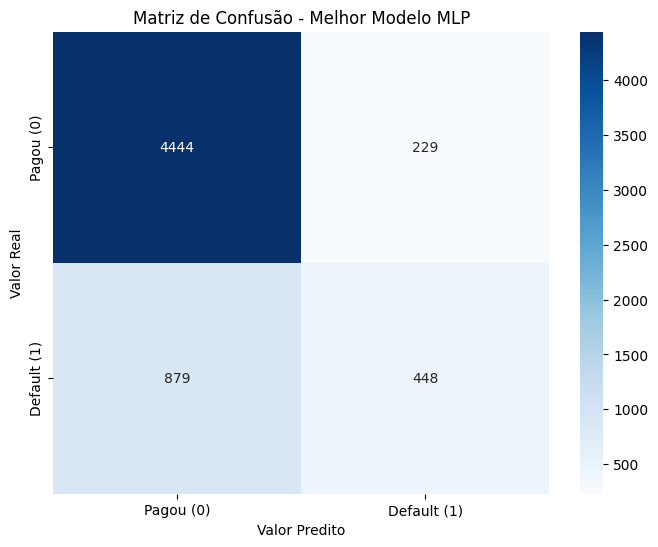

In [ ]:
# ==============================================================================
# RESOLUÇÃO DA LISTA DE EXERCÍCIOS 7 - REDES NEURAIS (MLP) - VERSÃO COLAB
# ==============================================================================

# 1. Importação das bibliotecas necessárias
# Começo importando todas as ferramentas que vou usar para manipulação de dados,
# pré-processamento, criação do modelo de rede neural e avaliação.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io # Necessário para ler o arquivo após o upload no Colab

# Importação específica para upload de arquivos no Google Colab
from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Configuração para exibir plots
%matplotlib inline

# ==============================================================================
# PASSO EXTRA: Upload do arquivo no Colab
# ==============================================================================
print("--- Por favor, faça o upload do arquivo CSV ---")
# Adicionei esta parte para permitir que eu selecione o arquivo diretamente do meu computador
# quando estiver rodando no Google Colab.
uploaded = files.upload()

# O nome do arquivo deve ser exatamente o que foi baixado.
# Vou verificar qual arquivo foi enviado para garantir que o código leia o certo.
nome_arquivo = next(iter(uploaded))
print(f"\nArquivo '{nome_arquivo}' carregado com sucesso!")


# ==============================================================================
# TAREFA 1: Pré-processamento dos Dados
# ==============================================================================
print("\n--- Iniciando o Pré-processamento ---")

# Carregando o dataset usando o io.BytesIO para ler o arquivo que acabou de ser enviado.
# Notei que o arquivo CSV tem uma primeira linha com IDs (X1, X2...) que não são os
# cabeçalhos reais. Os nomes das colunas estão na linha 1 (segunda linha).
# Por isso, usei header=1 para carregar corretamente.
df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]), header=1)

# Dando uma olhada rápida nas primeiras linhas para ver se carregou certo.
print("Primeiras linhas do dataset:")
display(df.head())

# Verificando informações gerais e se existem valores nulos (NaN).
# É importante garantir que não há dados faltando antes de treinar a rede.
print("\nInformações do dataset:")
df.info()

# Removendo a coluna 'ID'.
# Decidi remover essa coluna porque é apenas um identificador sequencial do cliente
# e não traz nenhuma informação preditiva sobre se ele vai pagar ou não.
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
    print("\nColuna 'ID' removida.")

# Renomeando a coluna alvo para facilitar o trabalho.
# O nome original 'default payment next month' é muito longo e tem espaços.
# Vou mudar para 'Default', onde 1 significa que não pagou e 0 que pagou.
df.rename(columns={'default payment next month': 'Default'}, inplace=True)

# Verificando o balanceamento das classes.
# É importante saber se temos muito mais exemplos de uma classe do que da outra,
# pois isso pode enviesar o modelo (a acurácia pode parecer alta, mas o modelo só chuta a classe majoritária).
print("\nContagem das classes alvo (0 = Pagou, 1 = Default):")
print(df['Default'].value_counts(normalize=True))
# Comentário sobre o resultado: Notei que os dados são desbalanceados (aprox. 78% não default e 22% default).
# Isso significa que a métrica F1-Score será mais importante que a Acurácia na avaliação.

# Separando as features (X) do alvo (y).
X = df.drop('Default', axis=1)
y = df['Default']

# Normalização dos dados (Scaling).
# Redes neurais funcionam muito melhor quando os dados de entrada estão na mesma escala.
# Usei o StandardScaler para padronizar as features (média 0 e desvio padrão 1),
# o que ajuda o algoritmo de otimização (como o Adam ou SGD) a convergir mais rápido.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nDados normalizados com StandardScaler.")

# ==============================================================================
# TAREFA 2: Divisão em Treino e Teste
# ==============================================================================
print("\n--- Dividindo os dados ---")

# Seguindo o pedido do professor, dividi os dados em 80% para treinamento e 20% para teste.
# Fixei o random_state=42 para garantir que, se eu rodar este código de novo,
# a divisão seja exatamente a mesma (reprodutibilidade).
# Usei stratify=y para garantir que a proporção de 'defaults' seja a mesma no treino e no teste,
# já que vimos que os dados são desbalanceados.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do conjunto de treino: {X_train.shape}")
print(f"Tamanho do conjunto de teste: {X_test.shape}")

# ==============================================================================
# TAREFA 3: Treinamento e Otimização de Hiperparâmetros (GridSearchCV)
# ==============================================================================
print("\n--- Iniciando a Otimização com GridSearchCV ---")
print("Isso pode levar alguns minutos, dependendo da combinação de parâmetros...")

# Definindo o modelo base.
# Configurei um max_iter alto (2000) para garantir que o solver 'sgd' (que é mais lento)
# tenha chance de convergir se for escolhido. O early_stopping=True ajuda a parar antes se não estiver melhorando.
mlp = MLPClassifier(random_state=42, max_iter=2000, early_stopping=True)

# Definindo a grade de parâmetros para testar, conforme solicitado.
# Estou testando diferentes arquiteturas de camadas ocultas, funções de ativação,
# e os solvers 'adam' e 'sgd'. Também variei o learning_rate para ajudar o SGD.
param_grid = {
    # Tuplas indicando neurônios por camada. Ex: (100, 50) são duas camadas ocultas.
    'hidden_layer_sizes': [(100,), (100, 50), (50, 30, 20)],
    'activation': ['relu', 'tanh'], # Funções de ativação populares
    'solver': ['adam', 'sgd'],      # Otimizadores solicitados
    'alpha': [0.0001, 0.01],        # Termo de regularização L2 para evitar overfitting
    'learning_rate_init': [0.001, 0.01] # Taxa de aprendizado inicial
}

# Configurando o GridSearchCV.
# Ele vai testar todas as combinações do param_grid usando validação cruzada (cv=3).
# Escolhi scoring='f1_macro' porque, como os dados são desbalanceados, a acurácia sozinha engana.
# O F1-score busca um equilíbrio melhor entre precisão e recall para ambas as classes.
# n_jobs=-1 usa todos os núcleos do processador para tentar acelerar.
grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1 # Mostra o progresso do treinamento
)

# Executando a busca (essa é a parte demorada).
grid_search.fit(X_train, y_train)

print("\n--- GridSearch Concluído ---")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor score (F1 Macro) na validação cruzada: {grid_search.best_score_:.4f}")

# Pegando o melhor modelo que o GridSearch encontrou já treinado com todos os dados de treino.
best_model = grid_search.best_estimator_

# ==============================================================================
# TAREFA 4: Avaliação do Modelo
# ==============================================================================
print("\n--- Avaliação no Conjunto de Teste ---")

# Usando o melhor modelo para fazer previsões nos dados de teste que ele nunca viu.
y_pred = best_model.predict(X_test)

# Calculando as métricas finais.
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro') # Usando macro para média balanceada entre classes

print(f"Acurácia no Teste: {accuracy:.4f}")
print(f"F1-Score (Macro) no Teste: {f1:.4f}")

print("\nRelatório de Classificação Completo:")
# O classification_report mostra Precisão, Recall e F1 para cada classe individualmente.
# É essencial para ver se o modelo está acertando bem a classe 1 (Default), que é a mais importante.
print(classification_report(y_test, y_pred))

print("Matriz de Confusão:")
# A matriz de confusão mostra visualmente onde o modelo acertou e errou.
# Linhas são os valores reais, colunas são as previsões.
cm = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão de forma mais bonita usando Seaborn.
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pagou (0)', 'Default (1)'],
            yticklabels=['Pagou (0)', 'Default (1)'])
plt.ylabel('Valor Real')
plt.xlabel('Valor Predito')
plt.title('Matriz de Confusão - Melhor Modelo MLP')
plt.show()

